In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing libraries for the GP.

In [8]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Creating a functions and drawing noisy observations from it.

In [16]:
#| echo: true
def f(x):
    return x * np.sin(x)

X = np.atleast_2d([1., 2.5, 3., 5., 6., 7., 8.]).T
y = f(X).ravel() + np.random.normal(0, 0.5, X.shape[0])

Training the model.

In [17]:
#| echo: true
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, alpha=0.1)
gp.fit(X, y)

GaussianProcessRegressor(alpha=0.1, kernel=1**2 * RBF(length_scale=10),
                         n_restarts_optimizer=9)

Plotting the prediction.

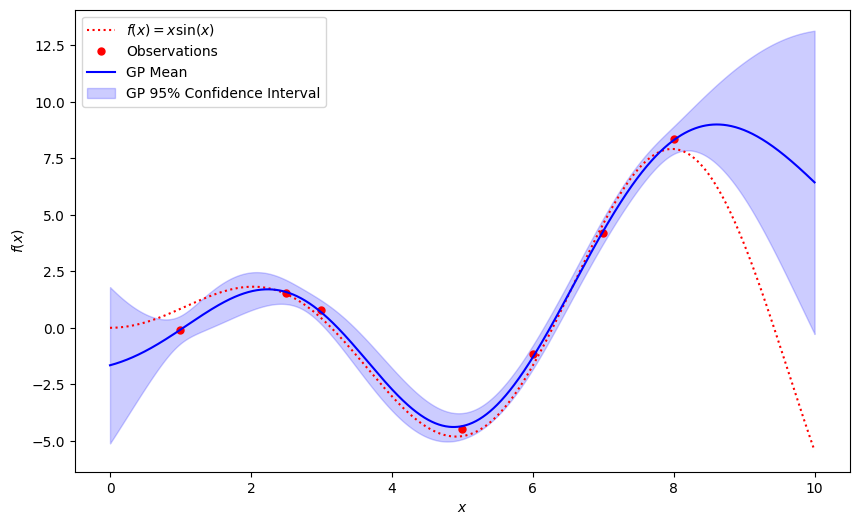

In [18]:
#| echo: true
x_range = np.atleast_2d(np.linspace(0, 10, 1000)).T
y_pred, sigma = gp.predict(x_range, return_std=True)

plt.figure(figsize=(10, 6))
plt.plot(x_range, f(x_range), 'r:', label=r'$f(x) = x \sin(x)$')
plt.plot(X, y, 'r.', markersize=10, label='Observations')
plt.plot(x_range, y_pred, 'b-', label='GP Mean')
plt.fill_between(x_range.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='GP 95% Confidence Interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend(loc='upper left')
plt.show()